Actividad 4.

1. Abstracto con motivacion y audiencia
2. Preguntas/Hipotesis que queremos resolver mediante el analisis de datos
3. Analisis Exploratorio de Datos (EDA)
4. Con base en las visualizaciones y resumenes numericos generados del desafıo anterior dar recomendaciones basados en los insights observados
5. Para esta oportunidad se deberan tener avances en los apartados: Definicion de objetivo, Contexto comercial, Problema Comercial, Contexto analıtico,
Exploracion de datos (EDA)


TITULO PROYECTO:

Estudio sobre el impacto del Covid-19 en Colombia: Analisis Exploratorio de Datos para el proyecto del Bootcamp en Data Science del instituto BIT, Febrero 2025

ABTRACT: 

La pandemia de COVID-19 tuvo un impacto significativo en la salud pública en Colombia, con variaciones en la mortalidad a lo largo del tiempo. Esta investigación analiza la relación entre la cantidad de vacunas administradas por tipo de laboratorio y la mortalidad asociada al virus en el país. Utilizando datos oficiales de salud pública, se aplican técnicas de análisis estadístico y modelos de correlación para identificar patrones entre la distribución de vacunas y la reducción de muertes. Los resultados de este estudio pueden contribuir a evaluar la efectividad de los distintos biológicos en la mitigación del impacto del virus y servir de base para futuras estrategias de salud pública.

PREGUNTA PROBLEMA:

¿Es posible clasificar la efectividad de las vacunas para COVID-19 apliacadas a lo del territorio Colombiano al comparar la taza de mortandad versus el laboratorio de la vacuna?

In [2]:
import pandas as pd

Vacunas = pd.read_csv("Asignacion_vacuna_contra_COVID-19.csv")
Muertes = pd.read_csv("Fallecidos_COVID_en_Colombia.csv")

Preguntas 

1. Cuantas muertes por covid-19 se reportan por region?
2. Cuantas vacunas se aplicaron discriminadas por laboratorio por cada region?
3. Existe relacion en el tipo de vacuna mas aplicada en cada region y cantidad de muertes.

In [3]:
# Agrupar Muertes por Region (Departamento)
muertes_por_region = Muertes.groupby('Nombre departamento').size().reset_index(name='Muertes')

# Por comodidad vamos a trabajar con el top 10 de regiones con mayor numero de muertes
top_regiones = muertes_por_region.nlargest(10, 'Muertes')


print(top_regiones)

   Nombre departamento  Muertes
5               BOGOTA    30293
1            ANTIOQUIA    18717
35               VALLE    15508
30           SANTANDER     8427
16        CUNDINAMARCA     7431
4         BARRANQUILLA     6030
25     NORTE SANTANDER     5211
3            ATLANTICO     4227
34              TOLIMA     4108
15             CORDOBA     4001


En esta parte se analizan los datos contentidos en el Dataframe Vacunas y se observa que algunas para el mismo labortatorio de vacunas el archivo las reporta con diferentes formas de escritura como como en el caso de Astrazeneca. Mismo escenario para los territorios.

Se normaliza la data y se filtra para tener una tabla con mejor visibilidad y que contenga solo la informacion deseable para el analisis.

Para normalizar la data se crean dos diccionarions que reemplazaran la informacion contenida en el dataset para grupar los laboratorios y los territorios.

In [4]:
# Normalizacion de las variables

labs_corrections = {
    'ASTRAZENECA': 'AZTRAZENECA',
    'astrezenca': 'AZTRAZENECA',  
    'pfizer': 'PFIZER',          
    'sinovac ': 'SINOVAC'         
}
Vacunas['Laboratorio_Vacuna'] = Vacunas['Laboratorio_Vacuna'].replace(labs_corrections)

territorio_corrections = {
    "ATLÁNTICO" : "ATLANTICO",
    'ATLANTICO' : 'ATLANTICO',
    'SANTA MARTHA' : 'SANTA MARTA',
    'SANTA MARTA' : 'SANTA MARTA',
    'BOGOTÁ D.C.' : 'BOGOTA D.C.',
    'BOGOTA D.C.' : 'BOGOTA D.C.',
    'BOYACÁ' : 'BOYACA',
    'BOYACA' : 'BOYACA',
    'CAQUETÁ' : 'CAQUETA',
    'CAQUETA' : 'CAQUETA',
    'CHOCÓ' : 'CHOCO',
    'CHOCO' : 'CHOCO',
    'CÓRDOBA' : 'CORDOBA',
    'CORDOBA' : 'CORDOBA',
    'LA_GUAJIRA' : 'LA GUAJIRA',
    'LA GUAJIRA' : 'LA GUAJIRA',
    'QUINDÍO' : 'QUINDIO',
    'QUINDIO' : 'QUINDIO',
    'VALLE_DEL_CAUCA' : 'VALLE DEL CAUCA',
    'VALLE DEL CAUCA' : 'VALLE DEL CAUCA',
    'VAUPÉS' :  'VAUPES',
    'VAUPES' :  'VAUPES',
    'SAN ANDRES, PROVIDENCIA Y SANTA CATALINA' :'SAN ANDRES',
    'BOLÍVAR' : 'BOLIVAR',
    'BOLIVAR': 'BOLIVAR'
}

Vacunas['Nom_Territorio'] = Vacunas['Nom_Territorio'].replace(territorio_corrections)

# Filtrado de Datos 

vacunas_filtradas = Vacunas[['Nom_Territorio', 'Laboratorio_Vacuna', 'Cantidad']].dropna()

vacunas_pivot = vacunas_filtradas.pivot_table(
    index='Nom_Territorio',
    columns='Laboratorio_Vacuna',
    values='Cantidad',
    aggfunc='sum',
    fill_value=0
).reset_index()

vacunas_pivot.columns.name = None  

print(vacunas_pivot)

        Nom_Territorio  AZTRAZENECA    JANSSEN    MODERNA     PFIZER  \
0             AMAZONAS       8076.0    28340.0    26180.0    18660.0   
1            ANTIOQUIA    2172290.0  1298092.6  2643216.0  3814188.0   
2               ARAUCA      59640.0    85950.0   107200.0   119064.0   
3            ATLANTICO     331250.0   221955.0   531060.0   642810.0   
4         BARRANQUILLA     409020.0   260435.0   674480.0  1013880.0   
5          BOGOTA D.C.    2429006.0  1414000.0  3416140.0  5427528.0   
6              BOLIVAR     296030.0   233510.0   392380.0   453156.0   
7               BOYACA     388354.0   334725.0   500440.0   653406.0   
8         BUENAVENTURA      50830.0    61830.0   103220.0    73758.0   
9               CALDAS     313360.0   167545.0   514040.0   622134.0   
10                CALI          0.0    38850.0   204100.0    70596.0   
11             CAQUETA      84020.0    75815.0   141320.0   154956.0   
12           CARTAGENA     277100.0   227120.0   392620.0   6371

In [5]:
import plotly.express as px

# Melt the pivoted DataFrame for Plotly
melted_data = vacunas_pivot.melt(
    id_vars='Nom_Territorio', 
    var_name='Laboratorio_Vacuna', 
    value_name='Cantidad'
)

melted_data['Cantidad'] = melted_data['Cantidad'].fillna(0)

# Plot a bar chart
fig = px.bar(
    melted_data,
    x='Laboratorio_Vacuna', 
    y='Cantidad', 
    color='Laboratorio_Vacuna',
    title='Vacunas aplicadas por laboratorio en todas las regiones',
    labels={'Laboratorio_Vacuna': 'Laboratorio', 'Cantidad': 'Cantidad Aplicada'}
)

# Display the chart
fig.show()

De acuerdo con lo anterior, las zonas que reportaron mas muertes por Covid-19 fueron Bogota, Antioqui, Valle del Cauca y Santander. 
En cuanto a las dosis aplicadas, el laboratorio que aplico mas vacunas en todo el territorio nacional fue Pfizer, seguido de Sinovac.

Existe relacion entre vacunas apliacadas y muertes por region?

In [6]:
vacunas_filtradas.rename(columns={"Nom_Territorio": "Nombre departamento"}, inplace=True)

vacunas_filtradas.columns = vacunas_filtradas.columns.str.strip()
top_regiones.columns = top_regiones.columns.str.strip()

#print("Vacunas columns:", vacunas_filtradas.columns.tolist())
#print("Muertes columns:", top_regiones.columns.tolist())

vacunas_filtradas.rename(columns={"Nombre departamento": "Departamento"}, inplace=True)
top_regiones.rename(columns={"Nombre departamento": "Departamento"}, inplace=True)

df_merged = pd.merge(top_regiones, vacunas_filtradas, on="Departamento")

print(df_merged.info())
print(df_merged.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1223 entries, 0 to 1222
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Departamento        1223 non-null   object 
 1   Muertes             1223 non-null   int64  
 2   Laboratorio_Vacuna  1223 non-null   object 
 3   Cantidad            1223 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 38.3+ KB
None
  Departamento  Muertes Laboratorio_Vacuna  Cantidad
0    ANTIOQUIA    18717             PFIZER    6570.0
1    ANTIOQUIA    18717            SINOVAC   10061.0
2    ANTIOQUIA    18717            SINOVAC   11106.0
3    ANTIOQUIA    18717             PFIZER    6438.0
4    ANTIOQUIA    18717             PFIZER   15060.0


Para el analisis de correlacion se utilizo el metodo "merge" para crear una columna en comun en ambos datastes la cual lleva como nombre "Departamento"

In [8]:
correlation_value = df_merged["Muertes"].corr(df_merged["Cantidad"])
print(f"Corelacion entre muertes y cantidad de vacuneas aplicadas: {correlation_value}")

Corelacion entre muertes y cantidad de vacuneas aplicadas: 0.43919942488017405


Una correlacion de 0.43 impliaca que, pese a que hay una correlacion positiva entre la cantidad de muertes por Covid-19 y la cantidad de dosis aplicadas, no es posible determinar que las muertes se deban a la aplicacion de vacunas. Se podria decir que a mayor cantidad de infectados, mayor cantidad de dosis aplicadas y que las muertes se pueden deber a la gravedad del brote de covid-19 y a otros factores externos, como la edad, enfermedades de base, entre otros.

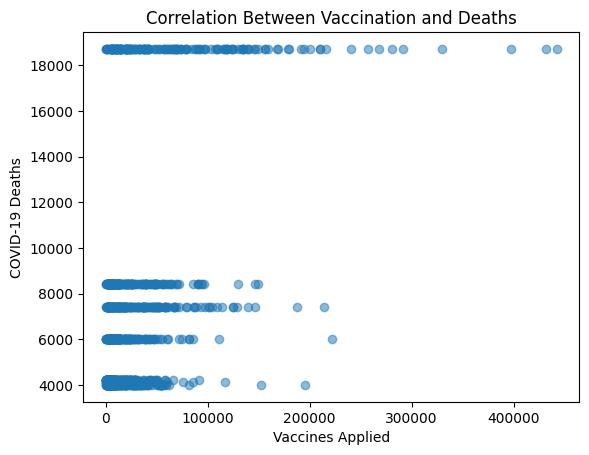

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df_merged["Cantidad"], df_merged["Muertes"], alpha=0.5)
plt.xlabel("Vaccines Applied")
plt.ylabel("COVID-19 Deaths")
plt.title("Correlation Between Vaccination and Deaths")
plt.show()